# Realist Vampire(s) Seeking Consenting Suicidal Person(s)

:::note
This is the companion notebook to the article *Realist Vampire(s) Seeking Consenting Suicidal Person(s)* (SAGT 2026, Springer LNCS) and to its extended version (available on HAL and arXiv). It is NOT intended to be self-contained. Please refer to the paper for context and explanations.
:::
<!-- TODO(Fabien): add the HAL link of the extended version once deposited, and the Springer DOI once the proceedings are out. -->

## Preliminaries

### Basic Blood Types

First, we define the different blood types. In addition to the $2^3$ main types depending on the presence of $A$, $B$, and $Rhesus$ markers, we add a void type that will be used later to model non-ghoul humans.

An important property is *can_feed*, that tells whether a vampire of a given type can feed on a ghoul of another type.

In [1]:
import numpy as np 

class BloodType:
    A = ["", "A"]
    B = ["", "B"]
    R = ["-", "+"]

    def __init__(self, i, j, k):
        self.markers = np.array([i, j, k])
        self.x = False

    def __repr__(self):
        if self.x:
            return 'X'
        i, j, k = self.markers
        result = f"{self.A[i]}{self.B[j]}{self.R[k]}"
        if len(result) == 1:
            return f"O{result}"
        else:
            return result

    @property
    def sanitized_name(self):
        res = self.__repr__()
        return res.replace('-','m').replace('+','p')

    def can_feed_on(self, other):
        return np.all(other.markers <= self.markers)

    @classmethod
    def void(cls):
        res = cls(1, 1, 1)
        res.x = True
        return res

Let us compute all possible groups. We'll store them in a list, a class, and a dict for easy access.

In [2]:
class Groups:
    pass

groups = [BloodType(i, j, k) for i in range(2) for j in range(2) for k in range(2)]
g = Groups
for t in groups:
    setattr(g, t.sanitized_name, t)
groups_ = {str(g): g for g in groups}

groups

[O-, O+, B-, B+, A-, A+, AB-, AB+]

### Vampire/Ghoul Types

We now define Vampire/Ghoul types, which are defined by two blood types. The following properties are defined:
- *autarkic*: the vampire can feed on their ghoul.
- *compatible_with*: each vampire of the two pairs can feed on the other pair's ghoul.
- *swinger*: a non plug-and-drink pair compatible with another non plug-and-drink pair.
- *helpless*: a non plug-and-drink pair that is only compatible with plug-and-drink pairs.
- *three_compatible*: each vampire of three pairs can feed on a distinct available ghoul, in a cyclic fashion.

In [3]:
class VGType:
    def __init__(self, v, g):
        self.v = v
        self.g = g
        self.compatible_types = []

    def __repr__(self):
        return f"{self.v}/{self.g}"

    @property
    def category(self):
        if self.auto_compatible:
            return "autarkic"
        if all(c.auto_compatible for c in self.compatible_types):
            return "helpless"
        return "swinger"
    
    @property
    def auto_compatible(self):
        return self.v.can_feed_on(self.g)

    def compatible_with(self, other):
        return self.v.can_feed_on(other.g) and other.v.can_feed_on(self.g)

    def three_cycle(self, other1, other2):
        return self.v.can_feed_on(other1.g) and other1.v.can_feed_on(other2.g) and other2.v.can_feed_on(self.g)
    
    def three_compatible_with(self, other1, other2):
        return self.three_cycle(other1, other2) or self.three_cycle(other2, other1)

We now prepare all possible VG pairs and observe their distribution.

In [4]:
from collections import Counter
vgs = [VGType(v, g) for v in groups for g in groups]
for v1 in vgs:
    for v2 in vgs:
        if v1.compatible_with(v2):
            v1.compatible_types.append(v2)
vgs_ = {str(vg): i for i, vg in enumerate(vgs)}
Counter(vg.category for vg in vgs)

Counter({'autarkic': 27, 'helpless': 19, 'swinger': 18})

### Human types

We call *human* a potential ghoul not yet affiliated to any vampire. Humans can be modelled as a VG pair where the vampire is a placeholder, denoted $X$, compatible with everyone, e.g. *X/O+*

In [5]:
class Human(VGType):
    category = "human"
    def __init__(self, g):
        self.v = BloodType.void() # alway compatible
        self.g = g

In [6]:
humans = [Human(g) for g in groups]
humans

[X/O-, X/O+, X/B-, X/B+, X/A-, X/A+, X/AB-, X/AB+]

### Blood type distribution

For numeric computation, we need statistics on the blood type probabilities. We leverage Wikipedia to access recent data.

In [7]:
import requests
import re
from bs4 import BeautifulSoup as bs
from fake_useragent import UserAgent
ua = UserAgent()
soup = bs(requests.get("https://en.wikipedia.org/wiki/Blood_type_distribution_by_country", headers={'User-Agent': ua.random}).content)

table = soup('table')[1]('tr')
names = [s.text.strip().replace("−", "-") for s in table[0]('th')[2:]]
blood_type_by_country = dict()
for line in table[1:]:
    try:
        country = line.th.text.strip().split('[')[0]
    except AttributeError:
        continue
    stats = {n: float(s.text.strip()[:-1]) if s.text[0].isdigit() else 0.0 for n, s in zip(names, line('td')[1:])}
    total = sum(stats.values())
    blood_type_by_country[country] = {k: v/total for k, v in stats.items()} 
    blood_type_by_country[country]['X'] = 1.0

In [8]:
blood_type_by_country['United States']

{'O+': 0.374,
 'A+': 0.35700000000000004,
 'B+': 0.085,
 'AB+': 0.034,
 'O-': 0.066,
 'A-': 0.063,
 'B-': 0.015,
 'AB-': 0.006,
 'X': 1.0}

In [9]:
blood_type_by_country['France']

{'O+': 0.365,
 'A+': 0.382,
 'B+': 0.077,
 'AB+': 0.025,
 'O-': 0.065,
 'A-': 0.068,
 'B-': 0.013999999999999999,
 'AB-': 0.004,
 'X': 1.0}

In [10]:
blood_type_by_country['World']

{'O+': 0.3878396121603878,
 'A+': 0.2757297242702757,
 'B+': 0.0818099181900818,
 'AB+': 0.0201999798000202,
 'O-': 0.1323098676901323,
 'A-': 0.0818099181900818,
 'B-': 0.0201999798000202,
 'AB-': 0.00010099989900010099,
 'X': 1.0}

Given a list of VG types and a country, issue normalized arrival rates.

In [11]:
def arrival_rates(vgs, country="United States"):
    probs = blood_type_by_country[country]
    res = [probs[str(vg.v)]*probs[str(vg.g)] for vg in vgs ]
    total = sum(res)
    return [r/total for r in res]

For the record, one can compute the distribution per VG category:

In [12]:
from collections import defaultdict
shares = defaultdict(float)
rates = arrival_rates(vgs)
for i, vg in enumerate(vgs):
    shares[vg.category] += float(100*rates[i])
dict(shares)

{'autarkic': 56.6078, 'helpless': 28.1786, 'swinger': 15.2136}

## Instability study

We know that the base model is not stabilisable. Yet, we can still investigate through simulations the practical performance of a robust matching algorithm in that setting.

Towards that goal, we write a function that converts a list of VG types into a matching problem.

In [13]:
import stochastic_matching as sm

def build_model(vgs, country="United States", self=True, relaxed=False, threesomes=False):
    edges = []
    n = len(vgs)
    for i, vg in enumerate(vgs):
        if relaxed or (self and vg.auto_compatible):
            edges.append([i])
        for j in range(i+1, n):
            if vg.compatible_with(vgs[j]):
                edges.append([i, j])
            if not threesomes:
                continue
            for k in range(j+1, n):
                if vg.three_compatible_with(vgs[j], vgs[k]):
                    if any(str(p.v)==str(p.g) for p in [vg, vgs[j], vgs[k]]):
                        continue
                    edges.append([i, j, k])
    incidence = np.zeros((n, len(edges)), dtype=int)
    for i, e in enumerate(edges):
        incidence[e, i] = 1
    model = sm.Model(incidence=incidence, names=[str(vg) for vg in vgs], 
                     rates=arrival_rates(vgs, country=country))
    model.cats = [vg.category for vg in vgs]
    model.edges = edges
    try:
        model.adjacency = sm.model.incidence_to_adjacency(model.incidence)
    except ValueError:
        pass
    return model

### Swingers-only

:::note
The compatibility graphs below are interactive VisJS widgets. They render when the notebook is executed locally (see the README for requirements); most static notebook viewers will not display them.
:::

We first focus on the interdependent types, because this subgraph is smaller and makes sense from a selfish perspective.

In [14]:
swingers = [vg for vg in vgs if vg.category == 'swinger']
s_model = build_model(swingers)
s_model.show_graph()

Nice structure.

In [15]:
s_model.kernel

Kernels of a graph with 18 nodes and 24 edges.
Node dimension is 0.
Edge dimension is 6
Type: Surjective-only
Node kernel:
[]
Edge kernel:
[[ 0.18564813 -0.18564813 -0.11463919  0.11463919  0.         -0.18564813
  -0.19214373  0.19214373  0.          0.11463919  0.19214373  0.
  -0.26575452  0.07361079 -0.48089508  0.36625589  0.07361079 -0.07361079
   0.36625589 -0.36625589  0.1392361   0.04641203  0.04641203 -0.04641203]
 [ 0.08466247 -0.08466247 -0.22494382  0.22494382  0.         -0.08466247
  -0.35173899  0.35173899  0.          0.22494382  0.35173899  0.
  -0.32129137 -0.03044762  0.10796964 -0.33291347 -0.03044762  0.03044762
  -0.33291347  0.33291347  0.06349685  0.02116562  0.02116562 -0.02116562]
 [ 0.3402013  -0.3402013   0.26340467 -0.26340467  0.         -0.3402013
   0.00616079 -0.00616079  0.         -0.26340467 -0.00616079  0.
  -0.06338772  0.06954851  0.29393959 -0.03053492  0.06954851 -0.06954851
  -0.03053492  0.03053492  0.50515097 -0.16494968 -0.16494968  0.16494

As predicted, it is not stabilisable.

In [16]:
s_model.stabilizable

False

### Helpless-excluded

Excluding helpless types is harsh but leads to strong stability.

We first remove the self-loops to have a simple graph to display (it is only for display).

In [17]:
helpfuls = [vg for vg in vgs if vg.category != 'helpless']
as_model = build_model(helpfuls, self=False)

colors = {"autarkic": "#00FF00", "swinger": "#FF8888", "helpless": "#FF0000"}
physics = {
    "solver": "barnesHut",
    "barnesHut": {
      "gravitationalConstant": -15000,  
      "centralGravity": 0.25,           
      "springLength": 200,              
      "springConstant": 0.0015,         
      "damping": 0.095,                 
      "avoidOverlap": 0.12              
    },
    "maxVelocity": 15,
    "stabilization": {
      "iterations": 800,
      "updateInterval": 25
    }
  }
nodes_info = [{"color": {"background": colors[vg.category]}} for vg in helpfuls]
options = {"width": "1000px", "nodes": {"font": {"size": 60}}, "physics": physics}
as_model.show_graph(vis_options=options, nodes_info=nodes_info)

Back to the real thing (with self-loops).

In [18]:
sa_model = build_model(helpfuls)
sa_model.kernel

Kernels of a graph with 45 nodes and 317 edges.
Node dimension is 0.
Edge dimension is 272
Type: Surjective-only
Node kernel:
[]
Edge kernel:
[[ 1.85577352e-01  4.60120460e-02  7.29821545e-02 ...  4.78644736e-04
  -1.19916425e-03 -1.67780899e-03]
 [ 1.70012321e-01  2.91401361e-02  6.69110172e-02 ...  2.85079976e-03
   9.21133624e-04 -1.92966614e-03]
 [ 1.51967077e-01  2.44349889e-02  7.03749366e-02 ... -1.77408140e-03
  -2.70700952e-04  1.50338044e-03]
 ...
 [-2.89699459e-02 -1.53198499e-02 -1.07370205e-02 ...  9.29353881e-01
  -6.42094593e-02  6.43665994e-03]
 [ 8.74057828e-03  8.55991905e-04  3.83245243e-04 ... -6.30747725e-02
   8.15041946e-01 -1.21883281e-01]
 [ 3.77105242e-02  1.61758418e-02  1.11202657e-02 ...  7.57134673e-03
  -1.20748594e-01  8.71680059e-01]]

In [19]:
sa_model.stabilizable

True

### All categories

We first remove the self-loops to have a simple graph to display (it is only for display).

In [20]:
full_model = build_model(vgs, self=False)
nodes_info = [{"color": {"background": colors[vg.category]}} for vg in vgs]
options = {"width": "1000px", "nodes": {"font": {"size": 60}}, "physics": physics}
full_model.show_graph(vis_options=options, nodes_info=nodes_info)

Back to the real thing.

In [21]:
full_model = build_model(vgs)
full_model.kernel

Kernels of a graph with 64 nodes and 378 edges.
Node dimension is 0.
Edge dimension is 314
Type: Surjective-only
Node kernel:
[]
Edge kernel:
[[-8.07660786e-02 -5.14815963e-03  1.55185186e-01 ...  1.23681204e-03
   1.07651019e-03 -1.60301853e-04]
 [-5.27865346e-02  1.35874032e-02  1.66497191e-01 ...  4.31476721e-03
   3.36397446e-03 -9.50792748e-04]
 [-7.31481008e-02 -1.48678109e-02  1.68269311e-01 ... -8.36046328e-04
   1.31250595e-03  2.14855228e-03]
 ...
 [ 1.05249784e-02  1.28211539e-02 -4.16977264e-02 ...  9.33214398e-01
  -5.95732615e-02  7.21234047e-03]
 [ 3.51189245e-02  1.37009886e-02 -1.00579058e-01 ... -5.94140329e-02
   8.18611345e-01 -1.21974622e-01]
 [ 2.45939461e-02  8.79834759e-04 -5.88813319e-02 ...  7.37156906e-03
  -1.21815393e-01  8.70813038e-01]]

In [22]:
full_model.stabilizable

False

### Threesomes

In [23]:
three = build_model(vgs, threesomes=True)
three.kernel

Kernels of a graph with 64 nodes and 4397 edges.
Node dimension is 0.
Edge dimension is 4333
Type: Surjective-only
Node kernel:
[]
Edge kernel:
[[ 3.89524050e-02 -9.99891026e-02  1.02077254e-02 ...  3.03768858e-04
   1.54222108e-04 -1.49546751e-04]
 [ 4.03133967e-02 -1.01467934e-01  1.12084971e-02 ... -3.78626371e-05
  -1.29415410e-04 -9.15527730e-05]
 [ 4.00204502e-02 -1.01827540e-01  1.07834303e-02 ... -3.54594281e-05
  -1.62044872e-04 -1.26585444e-04]
 ...
 [ 2.34574620e-03 -6.13999101e-03  5.82162293e-04 ...  9.96407855e-01
  -3.22429376e-03  3.67850837e-04]
 [-1.13259079e-02  2.88977694e-02 -3.03025921e-03 ... -3.23536900e-03
   8.71888904e-01 -1.24875727e-01]
 [-1.36716541e-02  3.50377604e-02 -3.61242151e-03 ...  3.56775597e-04
  -1.24886802e-01  8.74756422e-01]]

### Queue sizes on different setups

In [24]:
from stochastic_matching.simulator.metrics import StepsDone
def grouped_delay(simu):
    from collections import defaultdict
    import numpy as np
    wait = defaultdict(float)
    for i, cat in enumerate(simu.model.cats):
        wait[cat] += float(simu.avg_queues[i])
    return dict(wait)

**Warning:** we monitor queues with a null recurrent behaviour here, so we need to set a maximum queue size one order of magnitude higher than the square root of the number of steps.

In [25]:
base_params = {"simulator": "longest", "n_steps": 10**9, "max_queue": 400000, "seed": 42}
vq_params = {**base_params, "simulator": "virtual_queue"}

In [26]:
import multiprocess as mp
xps = sum([
    sm.XP("Swingers", model=build_model([vg for vg in vgs if vg.category == 'swinger']), **base_params),
    sm.XP("Helpfuls", model=build_model([vg for vg in vgs if vg.category != 'helpless']), **vq_params),
    sm.XP("No Swinger", model=build_model([vg for vg in vgs if vg.category != 'swinger']), **vq_params),
    sm.XP("All categories", model=build_model(vgs), **vq_params),
    sm.XP("threesomes allowed", model=build_model(vgs, threesomes=True), **vq_params)
])
with mp.Pool() as p:
    res = sm.evaluate(xps, [grouped_delay, StepsDone], pool=p)
res

  0%|          | 0/5 [00:00<?, ?it/s]

{'Swingers': {'grouped_delay': {'swinger': 43048.157124944},
  'steps_done': 1000000000},
 'Helpfuls': {'grouped_delay': {'autarkic': 4.162427954,
   'swinger': 10.752904849000002},
  'steps_done': 1000000000},
 'No Swinger': {'grouped_delay': {'autarkic': 0.005289561,
   'helpless': 55012.48222187699},
  'steps_done': 1000000000},
 'All categories': {'grouped_delay': {'autarkic': 0.0011420769999999998,
   'helpless': 49526.04985507099,
   'swinger': 10186.265578822002},
  'steps_done': 1000000000},
 'threesomes allowed': {'grouped_delay': {'autarkic': 265.46645575099996,
   'helpless': 21061.442134908,
   'swinger': 7806.321084564999},
  'steps_done': 1000000000}}

## Stairway to Stability

### Safety valves

In [27]:
model = build_model(vgs, relaxed=True)
base_params['simulator'] = 'virtual_queue'

In [28]:
model.kernel

Kernels of a graph with 64 nodes and 415 edges.
Node dimension is 0.
Edge dimension is 351
Type: Surjective-only
Node kernel:
[]
Edge kernel:
[[-6.66392973e-02  1.46326644e-01 -7.22319972e-03 ... -3.38870783e-04
  -1.48396032e-03 -1.14508953e-03]
 [-9.99357307e-02  1.29482979e-01 -1.12844994e-02 ... -1.31766036e-03
  -2.37050539e-03 -1.05284503e-03]
 [-2.67131450e-02  1.58095770e-01 -2.74271795e-03 ... -3.87754635e-04
  -1.69770748e-03 -1.30995284e-03]
 ...
 [ 1.23332381e-02 -3.49292348e-02 -3.68281453e-03 ...  9.33285059e-01
  -6.02510432e-02  6.46389731e-03]
 [-4.70729024e-03  1.05815809e-02 -7.12851020e-04 ... -5.92526383e-02
   8.18992064e-01 -1.21755297e-01]
 [-1.70405283e-02  4.55108156e-02  2.96996352e-03 ...  7.46230223e-03
  -1.20756893e-01  8.71780805e-01]]

In [29]:
model.stabilizable

True

In [30]:
base_params['max_queue'] = 20000
forbidden_edges = [i for i, e in enumerate(model.edges) 
                   if len(e)==1 and not vgs[e[0]].auto_compatible]
xp = sm.XP('discarding', model=model, 
           iterator=sm.Iterator('k', [2**i for i in range(1, 12)]), 
           forbidden_edges=forbidden_edges, **base_params)

In [31]:
import multiprocess as mp
with mp.Pool() as p:
    res = sm.evaluate(xp, ["regret", grouped_delay], pool=p)

  0%|          | 0/11 [00:00<?, ?it/s]

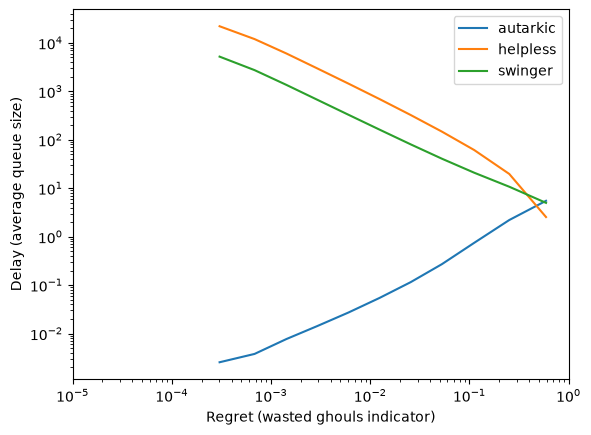

In [32]:
from matplotlib import pyplot as plt

r = res['discarding']
x = r['regret']
ys = r['grouped_delay']
for l in ys[0].keys():
    y = [yy[l] for yy in ys]
    plt.loglog(x, y, label=l)
plt.xlabel('Regret (wasted ghouls indicator)')
plt.ylabel('Delay (average queue size)')
plt.xlim([.00001, 1])
plt.legend()
import matplot2tikz
matplot2tikz.save("waste.tex")
plt.show()

### Humans

We now incorporate some amount of *humans* (vampire-free pre-ghouls) into the mix.

In [33]:
def mix_model(α = .001):
    μc = arrival_rates(vgs)
    μd = arrival_rates(humans)
    μ = [(1-α)*p/np.sum(μc) for p in μc]+[α*p/np.sum(μd) for p in μd]
    model = build_model(vgs+humans)
    model.rates = μ
    return model

:::note
If we try to numerically compute the minimum proportion of humans that allows the system to be stable, one gets a positive value. This is due to the numerical margin of error of the best positive solution. For highly skewed problems, it can be difficult to distinguish a zeroed edge from a barely positive one.

Yet, the value found has its own interest: it gives us a bound below which stability may be difficult to observe.
:::

In [34]:
def find_threshold(steps=20):
    u = 1.0
    l = 0.0
    for _ in range(steps):
        c = (u+l)/2
        m = mix_model(c)
        if m.stabilizable:
            u = c
        else:
            l = c
    return (u+l)/2
find_threshold()

0.0004916191101074219

In [35]:
xp = sm.XP('humanities', iterator=sm.Iterator('model', [2**i*.0005 for i in range(11)], 'alpha', lambda a: mix_model(a)), **base_params)

In [36]:
import multiprocess as mp
with mp.Pool() as p:
    res = sm.evaluate(xp, [grouped_delay], pool=p)

  0%|          | 0/11 [00:00<?, ?it/s]

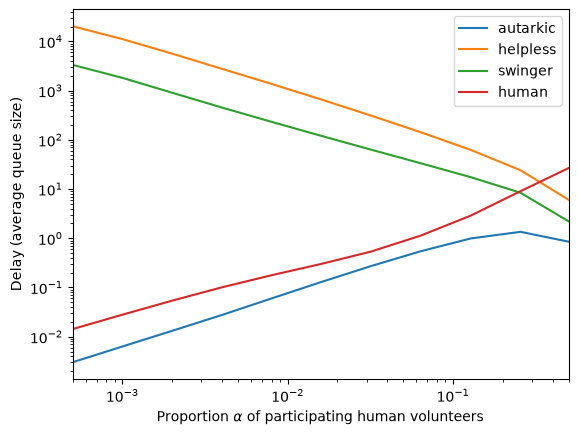

In [37]:
r = res['humanities']
x = r['alpha']
ys = r['grouped_delay']
for l in ys[0].keys():
    y = [e[l] for e in ys]
    plt.loglog(x, y, label=l)
plt.xlabel('Proportion $\\alpha$ of participating human volunteers')
plt.ylabel('Delay (average queue size)')
plt.xlim([.0005, .5])
plt.legend()
matplot2tikz.save("humans.tex")
plt.show()